# D.2 Domestic public funding on conservation and sustainable use of biodiversity and ecosystems

In [ ]:
# estándar
import ast
import json
import re
import time
import random
import threading
from collections import deque
from pathlib import Path
from urllib.parse import urlencode
from concurrent.futures import ThreadPoolExecutor, as_completed

# terceros
import requests
from requests.adapters import HTTPAdapter
import pandas as pd

from rapidfuzz import process, fuzz, distance

In [4]:
def build_url(base_url, params=None):
    """
    Arma un URL simple con query params.
    """
    if not params:
        return base_url

    return f"{base_url}?{urlencode(params, doseq=True)}"



    return results, failed
def fuzzy_match_mask(
    s: pd.Series,
    lookup: pd.Series,
    metric: str = "jaro_winkler",
    max_distance: float = 0.10,   # 0=igual, 1=distinto
) -> pd.Series:
    if not (0.0 <= max_distance <= 1.0):
        raise ValueError("max_distance debe estar en [0,1]")

    s_norm = s.astype("string").fillna("").str.upper().str.strip()
    choices = (
        lookup.astype("string").fillna("").str.upper().str.strip()
        .loc[lambda x: x.ne("")]
        .unique()
        .tolist()
    )

    m = metric.lower().strip()

    # --- métricas base: definimos SIMILARIDAD en [0,1] ---
    if m == "levenshtein":
        sim = lambda a, b: 1.0 - distance.Levenshtein.normalized_distance(a, b)

    elif m in ("damerau_levenshtein", "damerau-levenshtein"):
        sim = lambda a, b: 1.0 - distance.DamerauLevenshtein.normalized_distance(a, b)

    elif m == "jaro":
        sim = lambda a, b: distance.Jaro.similarity(a, b)

    elif m in ("jaro_winkler", "jaro-winkler"):
        sim = lambda a, b: distance.JaroWinkler.similarity(a, b)

    # --- wrappers tokenizados: NO son métricas base; entregan score 0..100 ---
    elif m in ("token_set_ratio", "token_set"):
        min_sim = 1.0 - max_distance
        cutoff_100 = min_sim * 100.0

        def _is_match(x: str) -> bool:
            if not x:
                return False
            return process.extractOne(
                x, choices,
                scorer=fuzz.token_set_ratio,
                score_cutoff=cutoff_100
            ) is not None

        return s_norm.map(_is_match)

    elif m in ("partial_token_set_ratio", "partial_token_set"):
        min_sim = 1.0 - max_distance
        cutoff_100 = min_sim * 100.0

        def _is_match(x: str) -> bool:
            if not x:
                return False
            return process.extractOne(
                x, choices,
                scorer=fuzz.partial_token_set_ratio,
                score_cutoff=cutoff_100
            ) is not None

        return s_norm.map(_is_match)

    else:
        raise ValueError(
            "metric debe ser: jaro, jaro_winkler, damerau_levenshtein, "
            "levenshtein, token_set_ratio, partial_token_set_ratio"
        )

    # caso métricas base: convertimos tu umbral de DISTANCIA a cutoff de SIMILARIDAD
    score_cutoff = 1.0 - max_distance

    def _is_match(x: str) -> bool:
        if not x:
            return False
        return process.extractOne(
            x, choices,
            scorer=sim,
            score_cutoff=score_cutoff
        ) is not None

    return s_norm.map(_is_match)

In [5]:
import pandas as pd
from rapidfuzz import process, fuzz, distance

from rapidfuzz import fuzz, distance

def _levenshtein(a, b, **kwargs):
    return 1.0 - distance.Levenshtein.normalized_distance(a, b)

def _damerau_levenshtein(a, b, **kwargs):
    return 1.0 - distance.DamerauLevenshtein.normalized_distance(a, b)

def _jaro(a, b, **kwargs):
    return distance.Jaro.similarity(a, b)

def _jaro_winkler(a, b, **kwargs):
    return distance.JaroWinkler.similarity(a, b)

def _token_set_ratio(a, b, **kwargs):
    return fuzz.token_set_ratio(a, b) / 100.0

def _partial_token_set_ratio(a, b, **kwargs):
    return fuzz.partial_token_set_ratio(a, b) / 100.0


SCORERS = {
    "levenshtein": _levenshtein,
    "damerau_levenshtein": _damerau_levenshtein,
    "damerau-levenshtein": _damerau_levenshtein,
    "jaro": _jaro,
    "jaro_winkler": _jaro_winkler,
    "jaro-winkler": _jaro_winkler,
    "token_set_ratio": _token_set_ratio,
    "token_set": _token_set_ratio,
    "partial_token_set_ratio": _partial_token_set_ratio,
    "partial_token_set": _partial_token_set_ratio,
}


def fuzzy_match_bidir(
    s: pd.Series,
    lookup: pd.Series,
    metric: str = "jaro_winkler",
    max_distance: float = 0.10,   # 0=igual, 1=distinto
) -> pd.DataFrame:
    """
    Matching bidireccional entre 2 Series (columna vs columna).

    Devuelve un DF con:
      - s_idx, s_raw, s_norm
      - lookup_idx, lookup_raw, lookup_norm
      - sim (0..1)
      - dist (0..1)
      - mutual (True si es mejor match recíproco)
    """
    if not (0.0 <= max_distance <= 1.0):
        raise ValueError("max_distance debe estar en [0,1]")

    # normalización (mantengo raw pa merge después)
    s_raw = s.copy()
    l_raw = lookup.copy()

    s_norm = s.astype("string").fillna("").str.upper().str.strip()
    l_norm = lookup.astype("string").fillna("").str.upper().str.strip()

    s_valid = s_norm.loc[s_norm.ne("")]
    l_valid = l_norm.loc[l_norm.ne("")]

    if s_valid.empty or l_valid.empty:
        return pd.DataFrame(columns=[
            "s_idx","s_raw","s_norm","lookup_idx","lookup_raw","lookup_norm",
            "sim","dist","mutual"
        ])


    m = metric.lower().strip()
    if m not in SCORERS:
        raise ValueError(
            "metric debe ser: jaro, jaro_winkler, damerau_levenshtein, "
            "levenshtein, token_set_ratio, partial_token_set_ratio"
        )
    scorer = SCORERS[m]
    cutoff = 1.0 - max_distance
    # --- forward: s -> lookup
    l_choices = l_valid.tolist()
    forward = {}
    for i, x in s_valid.items():
        hit = process.extractOne(x, l_choices, scorer=scorer, score_cutoff=cutoff)
        if hit is None:
            continue
        y, sim, _ = hit
        forward[i] = (y, float(sim))

    # --- backward: lookup -> s
    s_choices = s_valid.tolist()
    backward = {}
    for j, y in l_valid.items():
        hit = process.extractOne(y, s_choices, scorer=scorer, score_cutoff=cutoff)
        if hit is None:
            continue
        x, sim, _ = hit
        backward[j] = (x, float(sim))

    # index por valor normalizado pa poder “volver” (si hay duplicados, elegimos el mejor sim)
    # ojo: si tení muchos duplicados idénticos, esto se vuelve ambiguo (pero igual usable).
    best_s_idx_by_value = {}
    for i, x in s_valid.items():
        best_s_idx_by_value.setdefault(x, []).append(i)

    best_l_idx_by_value = {}
    for j, y in l_valid.items():
        best_l_idx_by_value.setdefault(y, []).append(j)

    rows = []
    # armamos filas desde forward y marcamos mutual si vuelve al mismo x
    for s_idx, (l_val, sim_fwd) in forward.items():
        x_val = s_valid.loc[s_idx]

        # buscamos algún lookup_idx representativo para ese l_val
        l_idxs = best_l_idx_by_value.get(l_val, [])
        lookup_idx = l_idxs[0] if l_idxs else pd.NA

        # chequeo recíproco: ese lookup (en backward) apunta a este mismo x?
        mutual = False
        sim_bwd = None

        if pd.notna(lookup_idx) and lookup_idx in backward:
            back_x_val, sim_bwd = backward[lookup_idx]
            mutual = (back_x_val == x_val)

        # score final: nos quedamos con el mejor (similaridad máxima = distancia mínima)
        sim_final = sim_fwd if sim_bwd is None else max(sim_fwd, sim_bwd)
        dist_final = 1.0 - sim_final

        rows.append({
            "s_idx": s_idx,
            "s_raw": s_raw.loc[s_idx],
            "lookup_idx": lookup_idx,
            "lookup_raw": (l_raw.loc[lookup_idx] if pd.notna(lookup_idx) else pd.NA),
            "dist": dist_final,
            "mutual": mutual,
        })

    out = pd.DataFrame(rows)

    # si querí “solo mutual best matches”, filtra así:
    # out = out[out["mutual"]]

    return out





# CARGADO DATOS TEPUAL

In [6]:
ponderaciones_tepual=pd.read_excel("BdD Sectoriales.xlsx")
ponderaciones_tepual=ponderaciones_tepual[['Nombre_Partida', 'Nombre_Programa', 'rownames', 'Partida', 'Capitulo','Programa','Total_partida', 'Categoría Globe', 'Subcategoría','Subsubcategoría', 'Porcentaje', 'Asignación']]
ponderaciones_tepual=ponderaciones_tepual.drop_duplicates()
ponderaciones_tepual=ponderaciones_tepual[~ponderaciones_tepual["Asignación"].isna()].drop_duplicates()

# CALCULO MIDESO

In [7]:

data_dir = Path("mideso")
files = sorted(data_dir.glob("DetalleTablero-*.xlsx"))

dfs = []
for fp in files:
    m = re.search(r"DetalleTablero-(\d{4})", fp.name)
    if m:
        df = pd.read_excel(fp)
        df["periodo"] = int(m.group(1))
        dfs.append(df)

mideso_all = pd.concat(dfs, ignore_index=True)
print(f"Shape: {mideso_all.shape}")
mideso_all.head()

/home/ricardo/Documents/IEB/BIODATA/vinculaciones/PNUD/7NR_ejecucion/D.2 Gasto público/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/ricardo/Documents/IEB/BIODATA/vinculaciones/PNUD/7NR_ejecucion/D.2 Gasto público/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/ricardo/Documents/IEB/BIODATA/vinculaciones/PNUD/7NR_ejecucion/D.2 Gasto público/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/ricardo/Documents/IEB/BIODATA/vinculaciones/PNUD/7NR_ejecucion/D.2 Gasto público/.venv/l

Shape: (41900, 12)


,CODIGO BIP,NOMBRE INICIATIVA,SECTOR,SUBSECTOR,RATE ACTUAL,AÑO ASIGNACION,INSTITUCION FINANCIERA PADRE,ASIGNADO VIGENTE,DEVENGADO AÑO,GASTO AÑO,COSTO TOTAL IDI M$,periodo
0,20039270-0,CONSTRUCCION CENTRO DE SALUD RURAL SECTOR OCO...,SALUD,BAJA COMPLEJIDAD,RS,2020,GOBIERNO REGIONAL,349803,180182.0,180182,2499445,2020
1,20054441-0,NORMALIZACION HOSPITAL DR. OSCAR HERNANDEZ ESC...,SALUD,BAJA COMPLEJIDAD,RS,2020,MINISTERIO DE SALUD,573188,525540.0,525540,26642764,2020
2,20075928-0,CONSTRUCCION CAMINO PENETRACION SAN JUAN-CABO ...,TRANSPORTE,TRANSPORTE CAMINERO,RS,2020,MINISTERIO DE OBRAS PUBLICAS,79500,NaN,0,4612949,2020
3,20075928-0,CONSTRUCCION CAMINO PENETRACION SAN JUAN-CABO ...,TRANSPORTE,TRANSPORTE CAMINERO,RS,2021,MINISTERIO DE OBRAS PUBLICAS,53890,53887.0,53887,4500887,2020
4,20075933-0,CONSTRUCCION CAMINO PENETRACION CALETA EUGENIA...,TRANSPORTE,TRANSPORTE CAMINERO,RS,2021,MINISTERIO DE OBRAS PUBLICAS,1285,176.0,176,1800373,2020


In [8]:
# Pre-compilar patrones
sectores = ["RECURSOS HIDRICOS", "TURISMO Y COMERCIO", "EDUCACION, CULTURA Y PATRIMONIO",
            "VIVIENDA Y DESARROLLO URBANO", "RECURSOS NATURALES Y MEDIO AMBIENTE", 
            "MULTISECTORIAL", "PESCA"]
subsectores_excluir = ["ARTE Y CULTURA", "AGUA POTABLE", "RIEGO", 
                        "SOLUCION HABITACIONAL PARCIAL O COMPLEMENTARIA",
                        "EDUCACION BASICA Y MEDIA", "EDUCACION DIFERENCIAL Y ESPECIAL",
                        "EDUCACION PARA ADULTOS", "ADMINISTRACION VIVIENDA",
                        "ADMINISTRACION  EDUCACION, CULTURA Y PATRIMONIO",
                        "ADMINISTRACION, COMERCIO Y TURISMO", "VIVIENDA DEFINITIVA"]
palabras_buenas = ["SUSTENT", "FAUNA", "ECOLO", "BIO", "SOSTEN", "CONSERVA",
                   "PARQUE", "PLAN DE DESARROLLO TURISTICO", "GLACIA", "NATURAL",
                   "SOSTENI", "RIBERAS", "PRESE", "PROTE", "FLORA", "RESTAU",
                   "BOTAN", "AMBIE", "DEGRADA", "CERRO", "HUMEDAL",
                   "REHABILITA", "ENRIQUEC", "FORESTAL", "NATIV", "INVASOR",
                   "RELLEN", "SANTUARIO", "SANITARIO", "INCENDIO", "CUENCA",
                   "EDUCACION AMBIENTAL", "ÁREA VERDE", "RECICLA", "RESIDUO",
                   "VULNERABILIDAD", "HIDROMÉTRICA", "HIDROMETRICA",
                   "TECHOS VERDES", "ALCANTARILLADO", "ENERGÍA RENOVABLE",
                   "CAMBIO CLIM"]
palabras_malas = ["RIEGO", "EMBALSE", "PRODUCCIÓN", "REGA", "BANDEJONES", "BERMAS",
                  "TRANQUES", "URB", "PLAZA", "CASA", "IGLESIA", "RECRE", "CULTU",
                  "MUSEO", "CAPILLA", "ADUANA", "TEATRO", "TEMPLO", "PALACIO",
                  "CASONA", "MURAL", "PARROQUIA", "FUERTE", "TELEFERICO",
                  "TELEFÉRICO", "DEPORT", "INFANTIL", "FACHADA", "MALL", "ZOO",
                  "ASCENSOR", "ZOFRI", "JARDÍN INFANTIL", "MERCADO", "LICEO",
                  "INTENDENCIA", "ESCUELA", "PUENTE", "VILLA", "EDIFICIO",
                  "EMPRESA", "BALNEARIO", "CEMENTERIO", "CALLE", "BODEGA",
                  "TORREONES", "GIMNASIO", "MARATHON", "MUELLE", "PLAYA",
                  "TELETON", "PARAPENTE", "NEUROCIENCIA", "CENTRO COMUNITARIO",
                  "CICLO", "COLECTOR", "VIALIDAD", "AVENIDA", "SALA CUNA",
                  "CATEDRAL", "BIBLIOTECA", "BARRIO", "MIRADOR", "ALUVION",
                  "CÁRCEL", "ESCALERA", "ESCALA", "COMUNITARIA", "AGUAS LLUVIA",
                  "PASAJE", "AGUA POTABLE RURAL", "CLUB", "HISTORICA", "SOCIAL",
                  "ARCHIVO", "BAÑO", "HABITACIO", "MAQUINA", "VEREDA",
                  "DEPENDENCIA", "FRONTERIZO", "MURO", "GOBIERNO", "ACERA",
                  "ALUMBRADO", "CAMINO", "PAVIMENTO", "VINIFI", "AUTOMO",
                  "RESIDENCIA", "PORTUARIA", "SEGURIDAD", "CANCHA", "VIVIE",
                  "NEGOCIO", "MARKETING", "VACUNA", "FORTIN", "FUNICULAR",
                  "CESFAM", "TRANSPORTE", "TERMIC", "COMPLEJO"]

patron_sectores = "|".join(map(re.escape, sectores))
patron_subsectores = "|".join(map(re.escape, subsectores_excluir))
patron_buenas = "|".join(map(re.escape, palabras_buenas))
patron_malas = "|".join(map(re.escape, palabras_malas))

# Aplicar todos los filtros de una
resultado = (
    mideso_all
    .loc[lambda x: x["SECTOR"].str.contains(patron_sectores, case=False, na=False)]
    .loc[lambda x: ~x["SUBSECTOR"].str.contains(patron_subsectores, case=False, na=False)]
    .loc[lambda x: x["NOMBRE INICIATIVA"].str.contains(patron_buenas, case=False, na=False)]
    .loc[lambda x: ~x["NOMBRE INICIATIVA"].str.contains(patron_malas, case=False, na=False)]
    .loc[lambda x: x["GASTO AÑO"] > 0]
    .copy()
)

print(f"Original: {len(mideso_all):,} → Filtrado: {len(resultado):,} ({len(resultado)/len(mideso_all)*100:.1f}%)")


Original: 41,900 → Filtrado: 744 (1.8%)


In [9]:
# Limpiar institución
resultado["INSTITUCION FINANCIERA PADRE"] = (
    resultado["INSTITUCION FINANCIERA PADRE"]
    .str.replace(r" -.*", "", regex=True)
)

# Mapeo de partidas
map_partida = {
    "GOBIERNO REGIONAL": 5, "MINISTERIO DE SALUD": 16,
    "MINISTERIO DE OBRAS PUBLICAS": 12, "MINISTERIO JUSTICIA Y DERECHOS HUMANOS": 10,
    "MINISTERIO DE VIVIENDA Y URBANISMO": 18, "MINISTERIO DEL INTERIOR": 5,
    "MINISTERIO PUBLICO": 23, "MINISTERIO DE RELACIONES EXTERIORES": 6,
    "MINISTERIO DE EDUCACION": 9, "MINISTERIO DE AGRICULTURA": 13,
    "DIRECCION DE BIBLIOTECAS, ARCHIVOS Y MUSEOS": 29,
    "CORPORACION DE FOMENTO DE LA PRODUCCION": 7,
    "SERVICIO DE GOBIERNO INTERIOR": 5
}
resultado["Partida"] = resultado["INSTITUCION FINANCIERA PADRE"].map(map_partida).astype("Int64")

# Multiplicadores (2020-2025)
multiplicadores = pd.DataFrame({
    "periodo": range(2020, 2026),
    "multiplicador": [1.436, 1.398, 1.367, 1.333, 1.294, 1.256]
})

a = resultado.merge(multiplicadores, on="periodo", how="left")
a["MONTO AJUSTADO M$"] = a["GASTO AÑO"] * a["multiplicador"]

print(f"Periodos: {sorted(a['periodo'].unique())}")
a.head()

Periodos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,CODIGO BIP,NOMBRE INICIATIVA,SECTOR,SUBSECTOR,RATE ACTUAL,AÑO ASIGNACION,INSTITUCION FINANCIERA PADRE,ASIGNADO VIGENTE,DEVENGADO AÑO,GASTO AÑO,COSTO TOTAL IDI M$,periodo,Partida,multiplicador,MONTO AJUSTADO M$
0,30002482-0,CONSTRUCCION SANEAMIENTO SANITARIO INTEGRAL SE...,RECURSOS HIDRICOS,EVACUACION DISPOSICION FINAL AGUAS SERVIDAS,RS,2021,GOBIERNO REGIONAL,138883,138883.0,138883,3076316,2020,5,1.436,199435.988
1,30068956-0,CONSTRUCCION REDES SANEAMIENTO SANITARIO SANTA...,RECURSOS HIDRICOS,EVACUACION DISPOSICION FINAL AGUAS SERVIDAS,RS,2021,GOBIERNO REGIONAL,79065,79065.0,79065,3610014,2020,5,1.436,113537.340
2,30068963-0,CONSTRUCCION REDES SANEAMIENTO SANITARIO SAN C...,RECURSOS HIDRICOS,EVACUACION DISPOSICION FINAL AGUAS SERVIDAS,RS,2021,GOBIERNO REGIONAL,275445,275445.0,275445,2136687,2020,5,1.436,395539.020
3,30075236-0,"MEJORAMIENTO CANALES CAUPOLICAN Y BANNEN, LOTA...",RECURSOS HIDRICOS,AGUAS LLUVIAS,RS,2021,MINISTERIO DE OBRAS PUBLICAS,1806316,1737844.0,1737844,15901409,2020,12,1.436,2495543.984
4,30075319-0,CONSTRUCCION ALCANTARILLADO Y TRATAMIENTO AGUA...,RECURSOS HIDRICOS,EVACUACION DISPOSICION FINAL AGUAS SERVIDAS,RS,2020,GOBIERNO REGIONAL,3586648,3586646.0,3586646,9651044,2020,5,1.436,5150423.656


## PLOT MIDESO

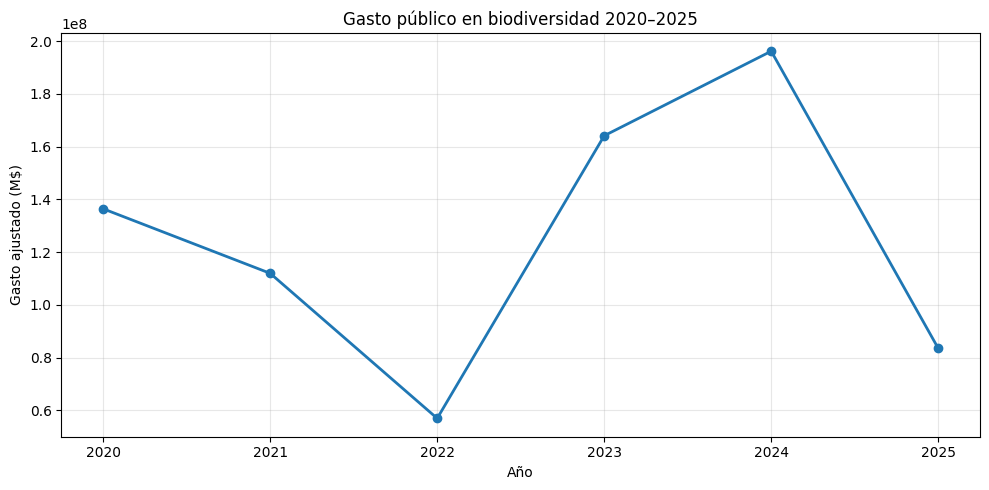

,periodo,MONTO AJUSTADO M$
0,2020,1.364285e+08
1,2021,1.119723e+08
2,2022,5.699627e+07
3,2023,1.641222e+08
4,2024,1.961678e+08
5,2025,8.353006e+07


In [ ]:
import matplotlib.pyplot as plt

gasto_anual = a.groupby("periodo", as_index=False)["MONTO AJUSTADO M$"].sum()

plt.figure(figsize=(10, 5))
plt.plot(gasto_anual["periodo"], gasto_anual["MONTO AJUSTADO M$"], marker="o", linewidth=2)
plt.xlabel("Año")
plt.ylabel("Gasto ajustado (M$)")
plt.title("Gasto MIDESO en biodiversidad 2020–2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gasto_anual

In [11]:
ponderaciones_tepual.columns

Index(['Nombre_Partida', 'Nombre_Programa', 'rownames', 'Partida', 'Capitulo',
       'Programa', 'Total_partida', 'Categoría Globe', 'Subcategoría',
       'Subsubcategoría', 'Porcentaje', 'Asignación'],
      dtype='object')

In [12]:
import pandas as pd
lookup_final=pd.read_csv("lookup_table_glosas_querybuild.csv")
# 1) reemplazar Asignación -> Ponderacion (rename nomás)
tepual = ponderaciones_tepual.rename(columns={"Asignación": "ponderacion"}).copy()

# 2) normalizar a MAYÚSCULAS pa no cagarla con strings
for col in ["Nombre_Partida", "Nombre_Programa", "rownames"]:
    tepual[col] = tepual[col].astype(str).str.upper()

for col in ["Nombre_Partida", "Nombre_Programa", "String_name"]:
    lookup_final[col] = lookup_final[col].astype(str).str.upper()

# 3) merge (match)
lookup_final = lookup_final.merge(
    tepual[
        ["Nombre_Partida", "Nombre_Programa", "rownames", "ponderacion"]
    ],
    left_on=["Nombre_Partida", "Nombre_Programa", "String_name"],
    right_on=["Nombre_Partida", "Nombre_Programa", "rownames"],
    how="left"
)

# 4) limpiar columna auxiliar
lookup_final = lookup_final.drop(columns=["rownames"])


In [13]:
setup_manual = [
    (
        "MINISTERIO DE AGRICULTURA",
        "INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAGROPECUARIA",
        "GASTO CORRIENTE",
        0.25
    ),
    (
        "MINISTERIO DE ECONOMÍA FOMENTO Y TURISMO",
        "SUBSECRETARIA DE PESCA",
        "FONDO DE INVESTIGACIÓN PESQUERA",
        0.25
    ),
    (
        "MINISTERIO DE ECONOMÍA FOMENTO Y TURISMO",
        "CORPORACIÓN DE FOMENTO DE LA PRODUCCIÓN",
        "INSTITUTO DE FOMENTO PESQUERO",
        0.25
    ),
    (
        "MINISTERIO DE INTERIOR",
        "POLICIA DE INVESTIGACIONES",
        "GASTO CORRIENTE",
        0.5
    ),
]

for partida, programa, string_name, pond in setup_manual:
    lookup_final.loc[
        (lookup_final["Nombre_Partida"] == partida) &
        (lookup_final["Nombre_Programa"] == programa) &
        (lookup_final["String_name"] == string_name),
        "ponderacion"
    ] = pond


In [14]:
lookup_final

,Nombre_Partida,Nombre_Programa,String_name,partida,capitulo,codigo_programa_presupuestario,area,subtitulo,item,asignacion,ponderacion
0,MINISTERIO DE AGRICULTURA,INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAG...,GASTO CORRIENTE,13,1,2.0,NaN,NaN,NaN,NaN,0.25
1,MINISTERIO DE AGRICULTURA,INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAG...,FIA,13,1,2.0,NaN,24.0,1.0,372.0,0.01
2,MINISTERIO DE AGRICULTURA,INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAG...,CIREN,13,1,2.0,NaN,24.0,1.0,374.0,0.25
3,MINISTERIO DE AGRICULTURA,INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAG...,INFOR,13,1,2.0,NaN,24.0,1.0,373.0,0.25
4,MINISTERIO DE AGRICULTURA,INVESTIGACIÓN E INNOVACIÓN TECNOLÓGICA SILVOAG...,INIA,13,1,2.0,NaN,24.0,1.0,371.0,0.25
...,...,...,...,...,...,...,...,...,...,...,...
139,MINISTERIO RELACIONES EXTERIORES,INSTITUTO ANTÁRTICO CHILENO,TÉSIS ANTÁRTICAS,6,4,1.0,NaN,24.0,1.0,24.0,0.75
140,MINISTERIO RELACIONES EXTERIORES,INSTITUTO ANTÁRTICO CHILENO,TÉSIS ANTÁRTICAS,6,4,1.0,NaN,24.0,3.0,24.0,0.75
141,MINISTERIO RELACIONES EXTERIORES,INSTITUTO ANTÁRTICO CHILENO,TÉSIS ANTÁRTICAS,6,4,1.0,NaN,24.0,8.0,24.0,0.75
142,MINISTERIO RELACIONES EXTERIORES,INSTITUTO ANTÁRTICO CHILENO,INVERSIÓN INFRAESTRUCTURA EN PLATAFORMAS CIENT...,6,4,1.0,NaN,24.0,3.0,46.0,0.25


# FILTRADO FINAL DEL QUERY

In [15]:
gastopublico=pd.read_csv("query_descargado_pagos_detallados.csv")
gastos_corriente=lookup_final[lookup_final.String_name=="GASTO CORRIENTE"]
gastos_prog=lookup_final[~(lookup_final.String_name=="GASTO CORRIENTE")]

In [16]:
df_filtrado = gastopublico.copy()
df_filtrado["ponderacion"] = pd.NA

cols = ["partida", "capitulo", "codigo_programa_presupuestario"]

mask = pd.Series(False, index=gastopublico.index)

for _, r in gastos_corriente.iterrows():
    m = pd.Series(True, index=gastopublico.index)
    for c in cols:
        if pd.notna(r[c]):
            m &= gastopublico[c] == r[c]

    # asignar ponderacion en el loop
    df_filtrado.loc[m, "ponderacion"] = r["ponderacion"]
    mask |= m

df_filtrado = df_filtrado[mask]
df_filtrado = df_filtrado[df_filtrado["subtitulo"].isin([21, 22, 29])]




In [17]:
df_filtrado_gast = gastopublico.copy()
df_filtrado_gast["ponderacion"] = pd.NA

cols = [
    "partida",
    "capitulo",
    "codigo_programa_presupuestario",
    "area",
    "subtitulo",
    "item",
    "asignacion"
]

mask = pd.Series(False, index=gastopublico.index)

for _, r in gastos_prog.iterrows():
    m = pd.Series(True, index=gastopublico.index)
    for c in cols:
        if pd.notna(r[c]):
            m &= gastopublico[c] == r[c]

    df_filtrado_gast.loc[m, "ponderacion"] = r["ponderacion"]
    mask |= m

df_filtrado_gast = df_filtrado_gast[mask]
df_filtrado_gast = df_filtrado_gast[
    ~df_filtrado_gast["subtitulo"].isin([21, 22, 29])
]



In [18]:
df_gastos_detalle= pd.concat([df_filtrado_gast, df_filtrado])
df_gastos_detalle["sump"] = df_gastos_detalle.apply(
    lambda r: r["sum"] * r["ponderacion"]
    if pd.notna(r["ponderacion"])
    else r["sum"],
    axis=1
)


In [20]:
df_gastos_detalle["sump"]

0        77341530.0
1        81365270.0
2        88515690.0
3        91869310.0
4        92903590.0
            ...    
75751      475000.0
75752      209999.0
75753      474810.0
75754    49685436.0
75755    19277000.0
Name: sump, Length: 72719, dtype: float64

In [21]:


partida_names = gastopublico[["partida", "nombre_partida"]].drop_duplicates()

# caracteres raros típicos de encoding roto
pat_raro = r"[�¿��]"

partida_names = (
    partida_names
    .assign(
        nombre_partida=lambda d: d["nombre_partida"].astype(str).str.strip(),
        is_clean=lambda d: ~d["nombre_partida"].str.contains(pat_raro, regex=True, na=False),
        name_len=lambda d: d["nombre_partida"].str.len(),
        _order=lambda d: range(len(d)),
    )
    # orden: limpio primero, luego más corto, luego estabilidad
    .sort_values(
        ["partida", "is_clean", "name_len", "_order"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates(subset="partida", keep="first")
    .drop(columns=["is_clean", "name_len", "_order"])
)


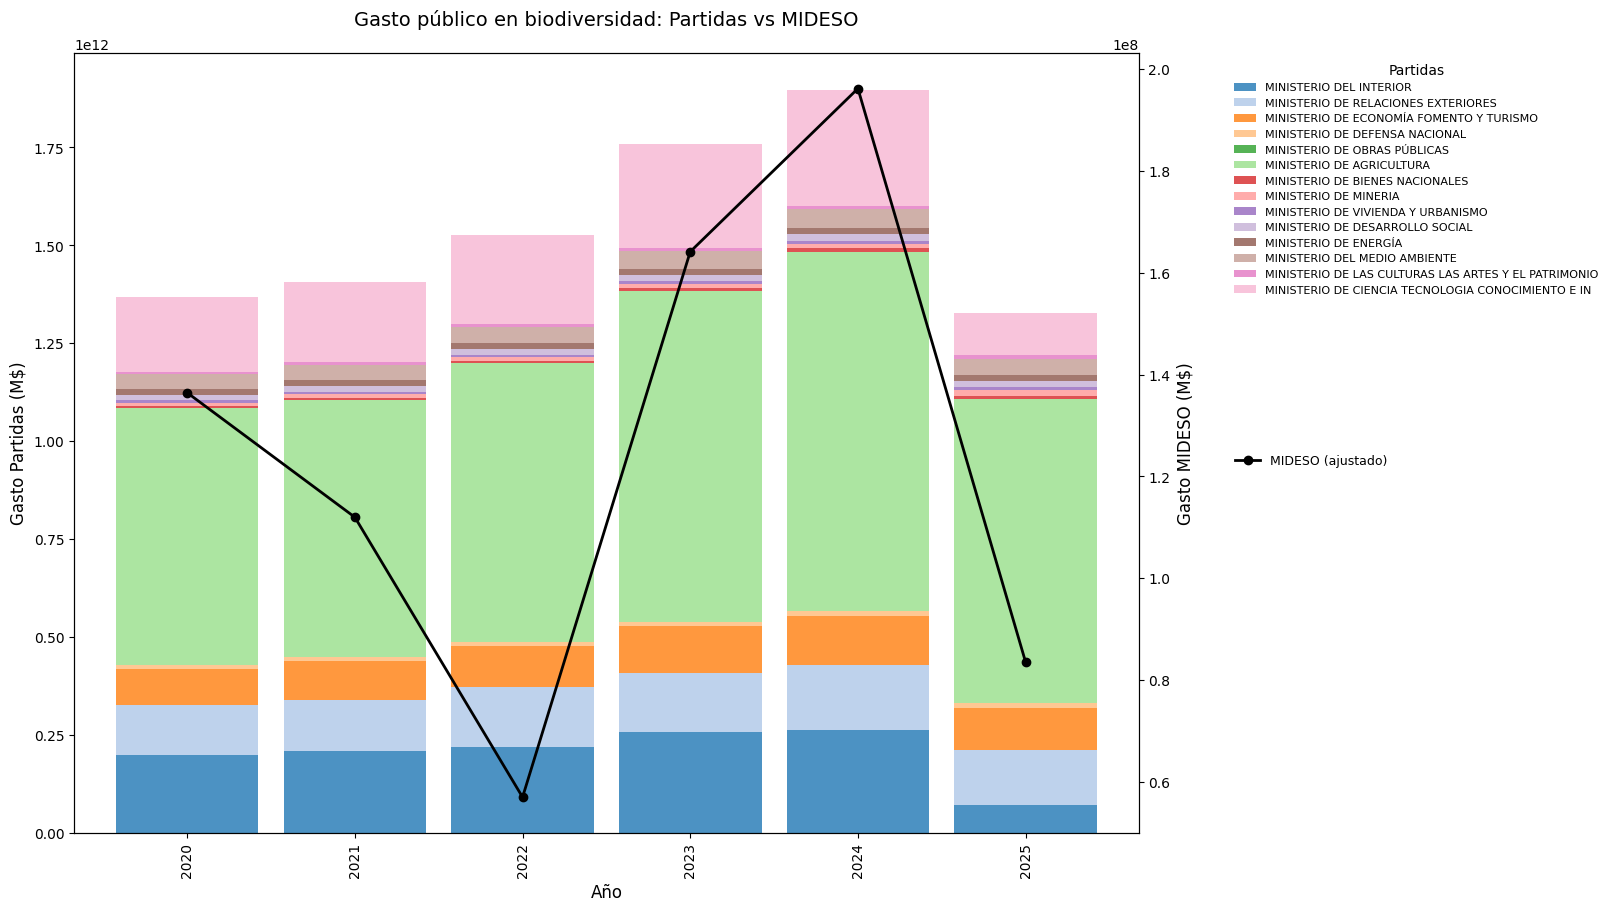

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1) Datos partidas
# -------------------------
df_grp = (
    df_gastos_detalle
    .dropna(subset=["partida"])
    .groupby(["periodo", "partida"], as_index=False)["sump"]
    .sum()
)

df_wide = (
    df_grp
    .pivot(index="periodo", columns="partida", values="sump")
    .fillna(0)
)

partida_map = (
    partida_names
    .drop_duplicates("partida")
    .set_index("partida")["nombre_partida"]
    .to_dict()
)

df_wide = df_wide.rename(columns=partida_map)
df_wide = df_wide.rename(columns=lambda c: c if isinstance(c, str) else f"PARTIDA {c}")

# -------------------------
# 2) Datos MIDESO (del análisis anterior)
# -------------------------
gasto_anual = a.groupby("periodo", as_index=False)["MONTO AJUSTADO M$"].sum()

# -------------------------
# 3) Plot con doble eje Y
# -------------------------
cmap = plt.get_cmap("tab20")
cols = list(df_wide.columns)
colors = [cmap(i % cmap.N) for i in range(len(cols))]

fig, ax1 = plt.subplots(figsize=(16, 9), constrained_layout=True)

# Eje izquierdo: barras apiladas (partidas)
df_wide.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=colors,
    legend=True,
    width=0.85,
    alpha=0.8
)

ax1.set_xlabel("Año", fontsize=12)
ax1.set_ylabel("Gasto Partidas (M$)", fontsize=12, color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_title("Gasto público en biodiversidad: Sectoriales y MIDESO", fontsize=14, pad=20)

# Eje derecho: línea (MIDESO)
ax2 = ax1.twinx()
ax2.plot(
    range(len(gasto_anual)),
    gasto_anual["MONTO AJUSTADO M$"],
    marker="o",
    linewidth=2,
    color="black",    label="MIDESO (ajustado)",
    zorder=10
)

ax2.set_ylabel("Gasto MIDESO (M$)", fontsize=12, color="black")
ax2.tick_params(axis="y", labelcolor="black")

# Leyendas
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1, l1,
    loc="upper left",
    bbox_to_anchor=(1.08, 1),
    frameon=False,
    fontsize=8,
    title="Partidas"
)

ax2.legend(
    h2, l2,
    loc="upper left",
    bbox_to_anchor=(1.08, 0.5),
    frameon=False,
    fontsize=9
)

plt.show()

In [31]:
# =========================
# Gasto anualizado total por Partidas (todos los ministerios)
# =========================

# Asegurar que el índice sea el periodo
df_partidas_anual = df_wide.copy()
df_partidas_anual.index = df_partidas_anual.index.astype(int)

# Sumar todas las columnas (ministerios) por año
gasto_partidas_anual = (
    df_partidas_anual
    .sum(axis=1, skipna=True)
    .rename("gasto_partidas")
    .reset_index()
    .rename(columns={"index": "periodo"})
)

gasto_partidas_anual



,periodo,gasto_partidas
0,2020,1.368323e+12
1,2021,1.407257e+12
2,2022,1.526464e+12
3,2023,1.758073e+12
4,2024,1.896211e+12
5,2025,1.327137e+12


In [33]:
# =========================
# Gasto anualizado MIDESO
# =========================

df_mideso_anual = gasto_anual.copy()

df_mideso_anual["periodo"] = df_mideso_anual["periodo"].astype(int)
df_mideso_anual["gasto_mideso"] = pd.to_numeric(
    df_mideso_anual["MONTO AJUSTADO M$"],
    errors="coerce"
)

df_mideso_anual = df_mideso_anual[["periodo", "gasto_mideso"]]

df_mideso_anual


,periodo,gasto_mideso
0,2020,1.364285e+08
1,2021,1.119723e+08
2,2022,5.699627e+07
3,2023,1.641222e+08
4,2024,1.961678e+08
5,2025,8.353006e+07


In [34]:
# =========================
# Gasto público total anual
# =========================

gasto_publico_anual = (
    gasto_partidas_anual
    .merge(df_mideso_anual, on="periodo", how="left")
)

# Si algún año no tiene MIDESO, asumir 0
gasto_publico_anual["gasto_mideso"] = (
    gasto_publico_anual["gasto_mideso"]
    .fillna(0)
)

# Suma total
gasto_publico_anual["gasto_publico_total"] = (
    gasto_publico_anual["gasto_partidas"]
    + gasto_publico_anual["gasto_mideso"]
)

gasto_publico_anual


,periodo,gasto_partidas,gasto_mideso,gasto_publico_total
0,2020,1.368323e+12,1.364285e+08,1.368460e+12
1,2021,1.407257e+12,1.119723e+08,1.407369e+12
2,2022,1.526464e+12,5.699627e+07,1.526521e+12
3,2023,1.758073e+12,1.641222e+08,1.758237e+12
4,2024,1.896211e+12,1.961678e+08,1.896407e+12
5,2025,1.327137e+12,8.353006e+07,1.327221e+12


In [37]:
# =========================
# Reordenar ministerios por peso promedio
# =========================

# --- Preparar datos de partidas (ministerios) ---
df_plot = df_wide.copy()
df_plot.index = df_plot.index.astype(int)

# --- Agregar MIDESO como columna ---
df_mideso_plot = (
    df_mideso_anual
    .set_index("periodo")[["gasto_mideso"]]
)

df_plot = df_plot.merge(
    df_mideso_plot,
    left_index=True,
    right_index=True,
    how="left"
)

df_plot["gasto_mideso"] = df_plot["gasto_mideso"].fillna(0)

# Renombrar para que sea explícito en la leyenda
df_plot = df_plot.rename(columns={
    "gasto_mideso": "MIDESO"
})


# df_plot ya contiene ministerios + MIDESO, con index = periodo

# 1) Calcular promedio temporal por institución
orden_ministerios = (
    df_plot
    .mean(axis=0, skipna=True)
    .sort_values(ascending=False)
)

orden_ministerios


MINISTERIO DE AGRICULTURA                               7.603332e+11
MINISTERIO DE CIENCIA TECNOLOGIA CONOCIMIENTO E IN      2.159540e+11
MINISTERIO DEL INTERIOR                                 2.025741e+11
MINISTERIO DE RELACIONES EXTERIORES                     1.443190e+11
MINISTERIO DE ECONOMÍA FOMENTO Y TURISMO                1.086204e+11
MINISTERIO DEL MEDIO AMBIENTE                           4.183868e+10
MINISTERIO DE ENERGÍA                                   1.538913e+10
MINISTERIO DE DESARROLLO SOCIAL                         1.512017e+10
MINISTERIO DE DEFENSA NACIONAL                          1.112110e+10
MINISTERIO DE MINERIA                                   1.066006e+10
MINISTERIO DE VIVIENDA Y URBANISMO                      7.765784e+09
MINISTERIO DE LAS CULTURAS LAS ARTES Y EL PATRIMONIO    7.100355e+09
MINISTERIO DE BIENES NACIONALES                         6.315316e+09
MINISTERIO DE OBRAS PÚBLICAS                            1.330423e+08
MIDESO                            

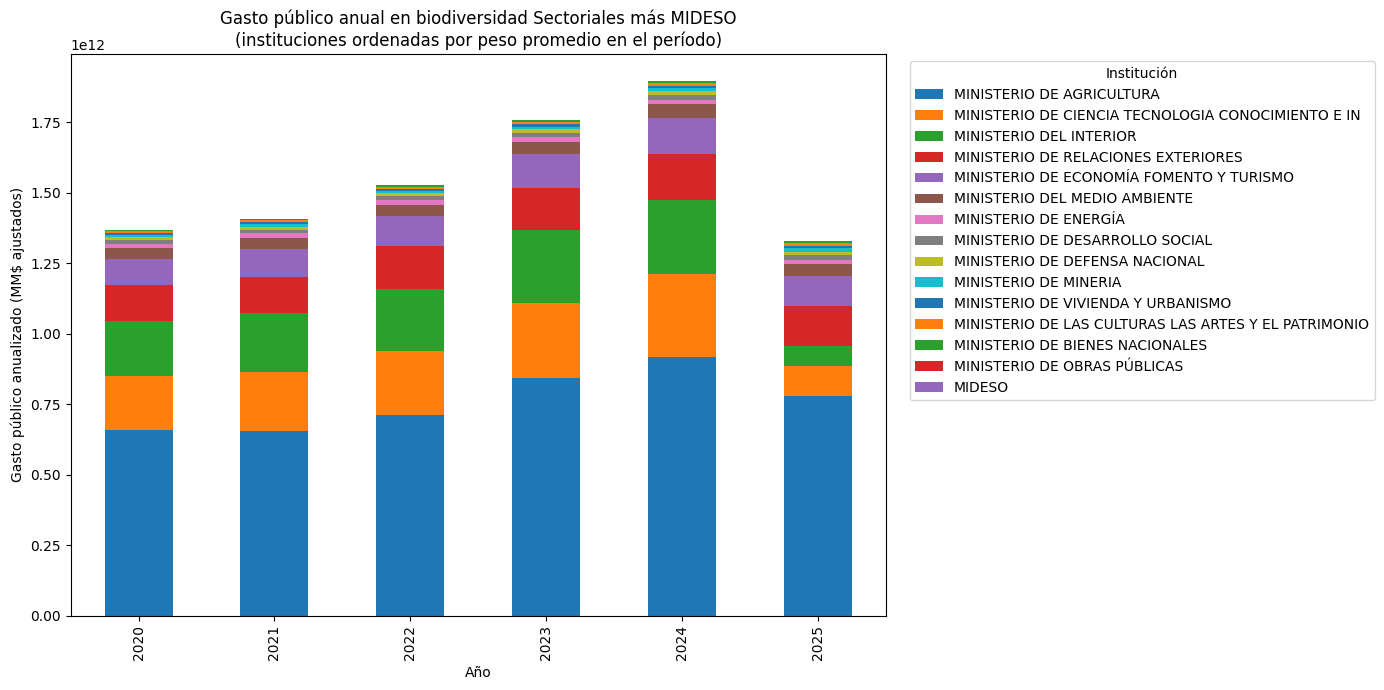

In [40]:
# =========================
# Plot: Gasto público anual (ordenado por peso promedio)
# =========================

import matplotlib.pyplot as plt

# 2) Reordenar columnas según peso promedio
df_plot_ordenado = df_plot[orden_ministerios.index]

df_plot_ordenado.head()


fig, ax = plt.subplots(figsize=(14, 7))

df_plot_ordenado.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel("Año")
ax.set_ylabel("Gasto público anualizado (MM$ ajustados)")
ax.set_title(
    "Gasto público anual en biodiversidad Sectoriales más MIDESO\n"
    "(instituciones ordenadas por peso promedio en el período)"
)

ax.legend(
    title="Institución",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
